# 載入資料集與預處理

In [38]:
from tensorflow.keras.datasets import mnist

(X_train_image, y_train_label), (X_test_image, y_test_label) = mnist.load_data()

# reshape 為2維array
x_train = X_train_image.reshape(-1, 784).astype('float32') # MNIST 原始圖片是 28x28 像素，將其攤平成784維的一維向量
x_test = X_test_image.reshape(-1, 784).astype('float32')

# 影像標準化處理
x_train_normalize = x_train / 255
x_test_normalize = x_test / 255

# 標籤進行One-hot Encoding
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train_label)
y_test_onehot = to_categorical(y_test_label)

In [39]:
print("Train Feature:", x_train_normalize.shape)
print("Train Label:", y_train_onehot.shape)
print("Test Feature:", x_test_normalize.shape)
print("Test Label:", y_test_onehot.shape)

Train Feature: (60000, 784)
Train Label: (60000, 10)
Test Feature: (10000, 784)
Test Label: (10000, 10)


# 建立模型

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# 隱藏層
model.add(Dense(
    input_dim=784,
    kernel_initializer='normal',
    units=1000,
    activation='relu'))
model.add(Dropout(0.5))

# 隱藏層
model.add(Dense(
    kernel_initializer='normal',
    units=1000,
    activation='relu'))
model.add(Dropout(0.5))

# 輸出層
model.add(Dense(
    units=10,
    kernel_initializer='normal',
    activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,796,010 (6.85 MB)

 Trainable params: 1,796,010 (6.85 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    metrics=['acc'],
    optimizer = 'adam',
    loss = 'categorical_crossentropy')

train_history = model.fit(
    x=x_train_normalize,
    y=y_train_onehot,
    validation_split=0.2, # 80%訓練，20%驗證
    epochs=10, # 訓練10次
    batch_size=200, # 每一批次200筆資料
    verbose = 1
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - acc: 0.8844 - loss: 0.3702 - val_acc: 0.9603 - val_loss: 0.1368
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - acc: 0.9499 - loss: 0.1646 - val_acc: 0.9676 - val_loss: 0.1034
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - acc: 0.9633 - loss: 0.1198 - val_acc: 0.9741 - val_loss: 0.0889
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - acc: 0.9704 - loss: 0.0951 - val_acc: 0.9756 - val_loss: 0.0847
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - acc: 0.9728 - loss: 0.0859 - val_acc: 0.9774 - val_loss: 0.0772
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - acc: 0.9778 - loss: 0.0712 - val_acc: 0.9760 - val_loss: 0.0794
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - acc: 0.9781 - loss: 0.0652 - val_acc: 0.9781 - val_loss: 0.0811
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - acc: 0.9801 - loss: 0.0612 - val_acc: 0.9778 - val_loss: 0.0821
Epoch 9/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 

# 圖形顯示過程

In [42]:
train_history.history

{'acc': [0.8843749761581421,
  0.949874997138977,
  0.9632916450500488,
  0.9704375267028809,
  0.9727916717529297,
  0.9777916669845581,
  0.9781458377838135,
  0.9800624847412109,
  0.9813125133514404,
  0.9825000166893005],
 'loss': [0.370158314704895,
  0.16458430886268616,
  0.11976159363985062,
  0.09508859366178513,
  0.08594717085361481,
  0.07116495817899704,
  0.06523513048887253,
  0.0611906535923481,
  0.05811100825667381,
  0.05149676650762558],
 'val_acc': [0.9603333473205566,
  0.9675833582878113,
  0.9740833044052124,
  0.9755833148956299,
  0.9774166941642761,
  0.9760000109672546,
  0.9780833125114441,
  0.9777500033378601,
  0.9775000214576721,
  0.9790833592414856],
 'val_loss': [0.13677042722702026,
  0.10337599366903305,
  0.08890929073095322,
  0.0846591666340828,
  0.07718660682439804,
  0.07940815389156342,
  0.08105546236038208,
  0.08211635053157806,
  0.08031418174505234,
  0.07481881976127625]}

In [43]:
train_history.history['acc']

[0.8843749761581421,
 0.949874997138977,
 0.9632916450500488,
 0.9704375267028809,
 0.9727916717529297,
 0.9777916669845581,
 0.9781458377838135,
 0.9800624847412109,
 0.9813125133514404,
 0.9825000166893005]

In [44]:
import matplotlib.pyplot as plt

def show_train_history(train_history, train_key, validation_key):
    plt.plot(train_history.history[train_key], '--')
    plt.plot(train_history.history[validation_key])
    plt.title('Train History')
    plt.ylabel(train_key)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

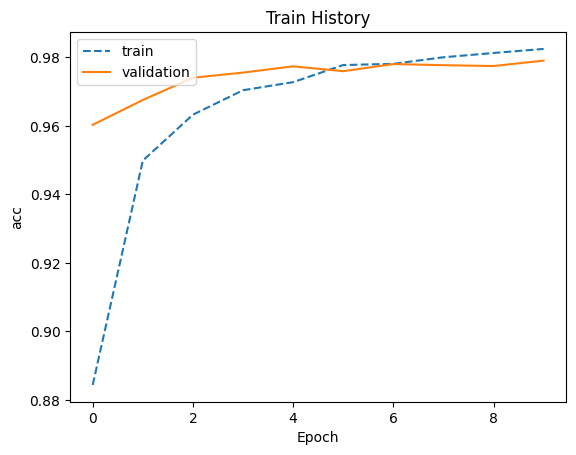

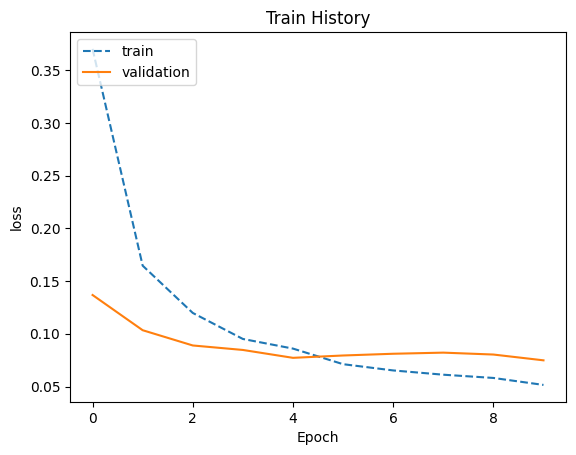

In [45]:
show_train_history(train_history, 'acc', 'val_acc')
show_train_history(train_history, 'loss', 'val_loss')

# 測試模型

In [46]:
scores = model.evaluate(x_test_normalize, y_test_onehot, verbose=2)
print('Test Accuracy:', scores[1])
print('Test Loss:', scores[0])

313/313 - 2s - 6ms/step - acc: 0.9820 - loss: 0.0638
Test Accuracy: 0.9819999933242798
Test Loss: 0.06375867128372192


In [51]:
import tensorflow as tf
import numpy as np

probability = model.predict(x_test_normalize)
prediction = tf.argmax(probability, axis=1).numpy()

# 查看前 10 筆預測結果
print(f"前 10 筆預測結果: {prediction[:10]}")
# 查看前 10 筆真實標籤
print(f"前 10 筆真實標籤: {y_test_label[:10]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
前 10 筆預測結果: [7 2 1 0 4 1 4 9 6 9]
前 10 筆真實標籤: [7 2 1 0 4 1 4 9 5 9]


In [52]:
print(probability[0])
print(prediction[0])
print('='*40)
for i in range(10):
  print(i ,'Prpbaility:%9f'%(probability[0][i]))

[4.9247734e-11 1.4022211e-09 1.5068910e-07 7.4210443e-06 4.8131274e-13
 2.1110789e-09 1.4865279e-13 9.9999219e-01 6.0130750e-10 2.8499090e-07]
7
0 Prpbaility: 0.000000
1 Prpbaility: 0.000000
2 Prpbaility: 0.000000
3 Prpbaility: 0.000007
4 Prpbaility: 0.000000
5 Prpbaility: 0.000000
6 Prpbaility: 0.000000
7 Prpbaility: 0.999992
8 Prpbaility: 0.000000
9 Prpbaility: 0.000000


# 混淆矩陣

In [53]:
import pandas as pd

cm = pd.crosstab(index=y_test_label, columns=prediction, rownames=['label'], colnames=['predict'])
cm

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,972,0,1,1,1,1,1,1,2,0
1,0,1126,2,1,0,2,2,0,2,0
2,3,0,1015,3,1,0,1,5,4,0
3,0,0,2,999,0,5,0,1,3,0
4,0,0,2,0,959,0,5,1,0,15
5,2,0,0,5,1,877,4,0,2,1
6,5,2,0,0,3,4,942,0,2,0
7,1,2,10,4,0,1,0,1005,1,4
8,0,0,4,11,1,6,2,3,943,4


In [54]:
error_indices = np.where(prediction != y_test_label)[0]

print(f"總共猜錯了 {len(error_indices)} 張圖片")

總共猜錯了 180 張圖片
